# Cargar z64

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import numpy as np
import pandas as pd

path = "/content/drive/MyDrive/BCAM/distr_sol_pv_segm_embeddings_v2.npz"

data = np.load(path, allow_pickle=True)

X = data["features"].astype(np.float32)
y = data["label"].astype(int)

print("X:", X.shape)
print("y:", y.shape)
print("\nDistribución de clases:")
print(pd.Series(y).value_counts())

Mounted at /content/drive
X: (20976, 64)
y: (20976,)

Distribución de clases:
1    10683
0    10293
Name: count, dtype: int64


# Split estratificado

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("train:", X_train.shape, np.unique(y_train, return_counts=True))
print("valid:", X_valid.shape, np.unique(y_valid, return_counts=True))
print("test :", X_test.shape, np.unique(y_test, return_counts=True))

train: (14683, 64) (array([0, 1]), array([7205, 7478]))
valid: (3146, 64) (array([0, 1]), array([1544, 1602]))
test : (3147, 64) (array([0, 1]), array([1544, 1603]))


# Escalado base

In [3]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

X_train_scaled: (14683, 64)
X_test_scaled : (3147, 64)


# Reconstrucción ICA 1–64

Reconstrucción ICA 1-64:   0%|          | 0/64 [00:00<?, ?it/s]

,ICA,MSE_train,MSE_test
0,1,3.021977e-01,2.986518e-01
1,2,1.544157e-01,1.585419e-01
2,3,8.701625e-02,8.923902e-02
3,4,4.846068e-02,4.898691e-02
4,5,3.418268e-02,3.432695e-02
...,...,...,...
59,60,1.534884e-05,1.577542e-05
60,61,1.060425e-05,1.129067e-05
61,62,6.533994e-06,7.028594e-06
62,63,2.649301e-06,2.771245e-06


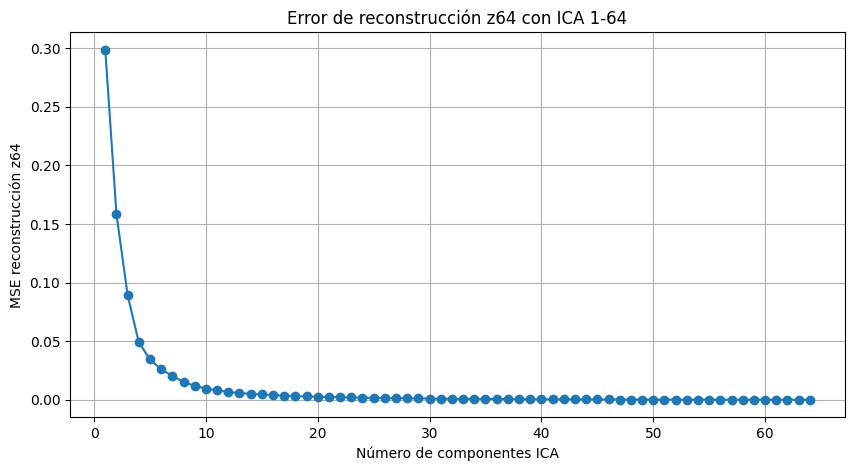

In [4]:
from sklearn.decomposition import FastICA
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm
import warnings

warnings.filterwarnings("ignore")

recon_results_ica = []

for k in tqdm(range(1, 65), desc="Reconstrucción ICA 1-64"):
    ica = FastICA(
        n_components=k,
        random_state=42,
        max_iter=3000,
        tol=1e-4,
        whiten="unit-variance"
    )

    Z_train = ica.fit_transform(X_train_scaled)
    X_train_rec = ica.inverse_transform(Z_train)

    Z_test = ica.transform(X_test_scaled)
    X_test_rec = ica.inverse_transform(Z_test)

    recon_results_ica.append({
        "ICA": k,
        "MSE_train": mean_squared_error(X_train_scaled, X_train_rec),
        "MSE_test": mean_squared_error(X_test_scaled, X_test_rec)
    })

df_recon_ica = pd.DataFrame(recon_results_ica)

display(df_recon_ica)

plt.figure(figsize=(10, 5))
plt.plot(df_recon_ica["ICA"], df_recon_ica["MSE_test"], marker="o")
plt.xlabel("Número de componentes ICA")
plt.ylabel("MSE reconstrucción z64")
plt.title("Error de reconstrucción z64 con ICA 1-64")
plt.grid(True)
plt.show()

# SVM RBF + ICA

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, roc_auc_score
from tqdm.auto import tqdm

results_svm_ica = []

for k in tqdm(range(1, 65), desc="SVM RBF ICA 1-64"):

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ica", FastICA(
            n_components=k,
            random_state=42,
            max_iter=3000,
            tol=1e-4,
            whiten="unit-variance"
        )),
        ("clf", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=False,
            cache_size=1000
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_score = model.decision_function(X_test)

    results_svm_ica.append({
        "Model": "SVM_RBF",
        "ICA": k,
        "Acc": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "bAcc": balanced_accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_score)
    })

df_svm_ica = pd.DataFrame(results_svm_ica)

display(df_svm_ica)

print("Mejor SVM por AUC:")
display(df_svm_ica.loc[[df_svm_ica["AUC"].idxmax()]])

SVM RBF ICA 1-64:   0%|          | 0/64 [00:00<?, ?it/s]

,Model,ICA,Acc,F1,bAcc,AUC
0,SVM_RBF,1,0.793454,0.789508,0.794085,0.838940
1,SVM_RBF,2,0.871306,0.859424,0.873198,0.929592
2,SVM_RBF,3,0.878297,0.867885,0.880084,0.937327
3,SVM_RBF,4,0.881157,0.871478,0.882879,0.934436
4,SVM_RBF,5,0.889418,0.880985,0.891060,0.937381
...,...,...,...,...,...,...
59,SVM_RBF,60,0.885923,0.877766,0.887486,0.937842
60,SVM_RBF,61,0.885605,0.877551,0.887150,0.937629
61,SVM_RBF,62,0.885288,0.877253,0.886827,0.937515
62,SVM_RBF,63,0.884970,0.876871,0.886515,0.936983


Mejor SVM por AUC:


,Model,ICA,Acc,F1,bAcc,AUC
50,SVM_RBF,51,0.885605,0.876881,0.887246,0.940075


In [6]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

print(df_svm_ica.to_string(index=False))

  Model  ICA      Acc       F1     bAcc      AUC
SVM_RBF    1 0.793454 0.789508 0.794085 0.838940
SVM_RBF    2 0.871306 0.859424 0.873198 0.929592
SVM_RBF    3 0.878297 0.867885 0.880084 0.937327
SVM_RBF    4 0.881157 0.871478 0.882879 0.934436
SVM_RBF    5 0.889418 0.880985 0.891060 0.937381
SVM_RBF    6 0.888783 0.880871 0.890341 0.938436
SVM_RBF    7 0.889736 0.881691 0.891324 0.939284
SVM_RBF    8 0.888783 0.880464 0.890401 0.938278
SVM_RBF    9 0.889418 0.881066 0.891048 0.936469
SVM_RBF   10 0.891643 0.883657 0.893244 0.936362
SVM_RBF   11 0.890690 0.882514 0.892308 0.933756
SVM_RBF   12 0.891643 0.883657 0.893244 0.934978
SVM_RBF   13 0.891643 0.883737 0.893232 0.934286
SVM_RBF   14 0.891325 0.883515 0.892896 0.933927
SVM_RBF   15 0.892278 0.884419 0.893867 0.932051
SVM_RBF   16 0.890372 0.882212 0.891984 0.933203
SVM_RBF   17 0.890690 0.882594 0.892296 0.934598
SVM_RBF   18 0.891007 0.883055 0.892596 0.934643
SVM_RBF   19 0.891007 0.883055 0.892596 0.934178
SVM_RBF   20 0.89037

# Random Forest + ICA

In [7]:
from sklearn.ensemble import RandomForestClassifier
from tqdm.auto import tqdm

results_rf_ica = []

for k in tqdm(range(1, 65), desc="Random Forest ICA 1-64"):

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ica", FastICA(
            n_components=k,
            random_state=42,
            max_iter=3000,
            tol=1e-4,
            whiten="unit-variance"
        )),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results_rf_ica.append({
        "Model": "Random_Forest",
        "ICA": k,
        "Acc": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "bAcc": balanced_accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })

df_rf_ica = pd.DataFrame(results_rf_ica)

display(df_rf_ica)

print("Mejor Random Forest por AUC:")
display(df_rf_ica.loc[[df_rf_ica["AUC"].idxmax()]])

Random Forest ICA 1-64:   0%|          | 0/64 [00:00<?, ?it/s]

,Model,ICA,Acc,F1,bAcc,AUC
0,Random_Forest,1,0.702256,0.703199,0.702443,0.807852
1,Random_Forest,2,0.855418,0.850673,0.856315,0.919387
2,Random_Forest,3,0.878615,0.873844,0.879633,0.932833
3,Random_Forest,4,0.881474,0.876449,0.882547,0.933799
4,Random_Forest,5,0.884652,0.879282,0.885797,0.932520
5,Random_Forest,6,0.889418,0.884385,0.890548,0.942311
6,Random_Forest,7,0.885923,0.880929,0.887021,0.940571
7,Random_Forest,8,0.886241,0.881063,0.887369,0.939300
8,Random_Forest,9,0.883381,0.878114,0.884502,0.943453
9,Random_Forest,10,0.883699,0.878244,0.884850,0.940522


Mejor Random Forest por AUC:


,Model,ICA,Acc,F1,bAcc,AUC
8,Random_Forest,9,0.883381,0.878114,0.884502,0.943453


In [8]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

print(df_rf_ica.to_string(index=False))

        Model  ICA      Acc       F1     bAcc      AUC
Random_Forest    1 0.702256 0.703199 0.702443 0.807852
Random_Forest    2 0.855418 0.850673 0.856315 0.919387
Random_Forest    3 0.878615 0.873844 0.879633 0.932833
Random_Forest    4 0.881474 0.876449 0.882547 0.933799
Random_Forest    5 0.884652 0.879282 0.885797 0.932520
Random_Forest    6 0.889418 0.884385 0.890548 0.942311
Random_Forest    7 0.885923 0.880929 0.887021 0.940571
Random_Forest    8 0.886241 0.881063 0.887369 0.939300
Random_Forest    9 0.883381 0.878114 0.884502 0.943453
Random_Forest   10 0.883699 0.878244 0.884850 0.940522
Random_Forest   11 0.884017 0.878617 0.885162 0.942326
Random_Forest   12 0.879250 0.874089 0.880328 0.937677
Random_Forest   13 0.877344 0.872185 0.878409 0.940478
Random_Forest   14 0.879886 0.875083 0.880916 0.937300
Random_Forest   15 0.876708 0.872452 0.877642 0.934835
Random_Forest   16 0.877026 0.872823 0.877954 0.933099
Random_Forest   17 0.873213 0.868793 0.874151 0.932753
Random_For

# Logistic Regression + ICA

In [9]:
from sklearn.linear_model import LogisticRegression
from tqdm.auto import tqdm

results_lr_ica = []

for k in tqdm(range(1, 65), desc="Logistic Regression ICA 1-64"):

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ica", FastICA(
            n_components=k,
            random_state=42,
            max_iter=3000,
            tol=1e-4,
            whiten="unit-variance"
        )),
        ("clf", LogisticRegression(
            max_iter=5000,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results_lr_ica.append({
        "Model": "Logistic_Regression",
        "ICA": k,
        "Acc": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "bAcc": balanced_accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })

df_lr_ica = pd.DataFrame(results_lr_ica)

display(df_lr_ica)

print("Mejor Logistic Regression por AUC:")
display(df_lr_ica.loc[[df_lr_ica["AUC"].idxmax()]])

Logistic Regression ICA 1-64:   0%|          | 0/64 [00:00<?, ?it/s]

,Model,ICA,Acc,F1,bAcc,AUC
0,Logistic_Regression,1,0.794407,0.786398,0.795390,0.873362
1,Logistic_Regression,2,0.872259,0.863636,0.873752,0.917170
2,Logistic_Regression,3,0.887194,0.880189,0.888603,0.933417
3,Logistic_Regression,4,0.885923,0.878757,0.887343,0.931413
4,Logistic_Regression,5,0.891643,0.884914,0.893053,0.943695
5,Logistic_Regression,6,0.887512,0.880808,0.888879,0.944513
6,Logistic_Regression,7,0.889101,0.882373,0.890486,0.944795
7,Logistic_Regression,8,0.889101,0.882373,0.890486,0.944828
8,Logistic_Regression,9,0.889418,0.882749,0.890798,0.944628
9,Logistic_Regression,10,0.887512,0.880968,0.888855,0.944240


Mejor Logistic Regression por AUC:


,Model,ICA,Acc,F1,bAcc,AUC
23,Logistic_Regression,24,0.89482,0.889038,0.896112,0.948203


In [10]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

print(df_lr_ica.to_string(index=False))

              Model  ICA      Acc       F1     bAcc      AUC
Logistic_Regression    1 0.794407 0.786398 0.795390 0.873362
Logistic_Regression    2 0.872259 0.863636 0.873752 0.917170
Logistic_Regression    3 0.887194 0.880189 0.888603 0.933417
Logistic_Regression    4 0.885923 0.878757 0.887343 0.931413
Logistic_Regression    5 0.891643 0.884914 0.893053 0.943695
Logistic_Regression    6 0.887512 0.880808 0.888879 0.944513
Logistic_Regression    7 0.889101 0.882373 0.890486 0.944795
Logistic_Regression    8 0.889101 0.882373 0.890486 0.944828
Logistic_Regression    9 0.889418 0.882749 0.890798 0.944628
Logistic_Regression   10 0.887512 0.880968 0.888855 0.944240
Logistic_Regression   11 0.888147 0.881561 0.889503 0.944018
Logistic_Regression   12 0.889101 0.882373 0.890486 0.944617
Logistic_Regression   13 0.890690 0.883784 0.892117 0.945254
Logistic_Regression   14 0.890690 0.884175 0.892058 0.944335
Logistic_Regression   15 0.891007 0.884628 0.892358 0.945086
Logistic_Regression   16

# Resultados ICA

In [11]:
df_all_ica = pd.concat([df_svm_ica, df_rf_ica, df_lr_ica], ignore_index=True)

display(df_all_ica)

print("Mejor resultado por modelo:")
display(
    df_all_ica.loc[df_all_ica.groupby("Model")["AUC"].idxmax()]
    .sort_values("AUC", ascending=False)
)

,Model,ICA,Acc,F1,bAcc,AUC
0,SVM_RBF,1,0.793454,0.789508,0.794085,0.838940
1,SVM_RBF,2,0.871306,0.859424,0.873198,0.929592
2,SVM_RBF,3,0.878297,0.867885,0.880084,0.937327
3,SVM_RBF,4,0.881157,0.871478,0.882879,0.934436
4,SVM_RBF,5,0.889418,0.880985,0.891060,0.937381
5,SVM_RBF,6,0.888783,0.880871,0.890341,0.938436
6,SVM_RBF,7,0.889736,0.881691,0.891324,0.939284
7,SVM_RBF,8,0.888783,0.880464,0.890401,0.938278
8,SVM_RBF,9,0.889418,0.881066,0.891048,0.936469
9,SVM_RBF,10,0.891643,0.883657,0.893244,0.936362


Mejor resultado por modelo:


,Model,ICA,Acc,F1,bAcc,AUC
151,Logistic_Regression,24,0.894820,0.889038,0.896112,0.948203
72,Random_Forest,9,0.883381,0.878114,0.884502,0.943453
50,SVM_RBF,51,0.885605,0.876881,0.887246,0.940075


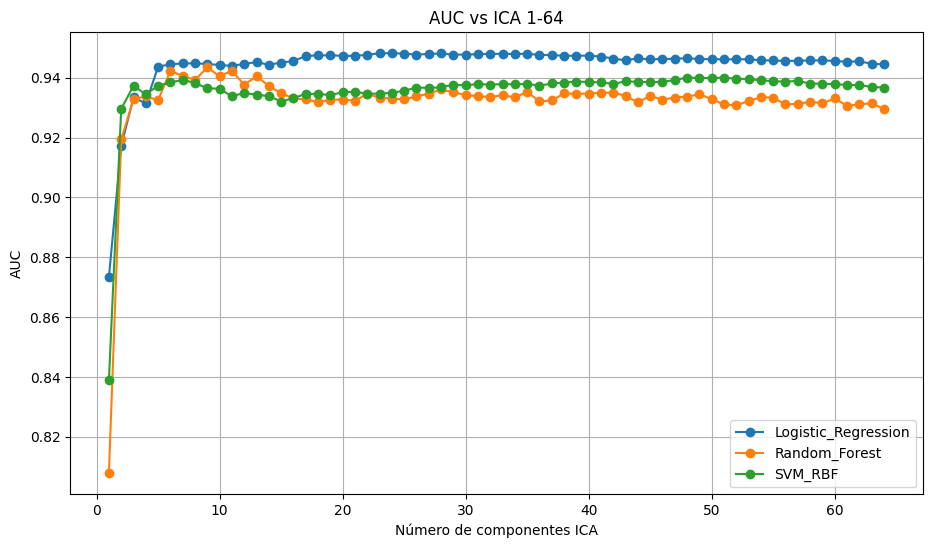

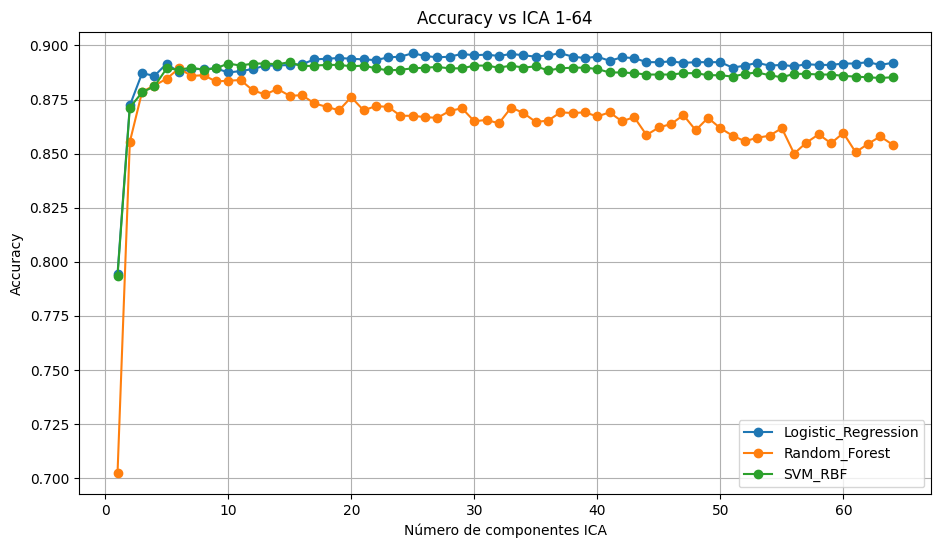

In [12]:
plt.figure(figsize=(11, 6))

for model_name, df_m in df_all_ica.groupby("Model"):
    plt.plot(df_m["ICA"], df_m["AUC"], marker="o", label=model_name)

plt.xlabel("Número de componentes ICA")
plt.ylabel("AUC")
plt.title("AUC vs ICA 1-64")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(11, 6))

for model_name, df_m in df_all_ica.groupby("Model"):
    plt.plot(df_m["ICA"], df_m["Acc"], marker="o", label=model_name)

plt.xlabel("Número de componentes ICA")
plt.ylabel("Accuracy")
plt.title("Accuracy vs ICA 1-64")
plt.grid(True)
plt.legend()
plt.show()